# 07c — Dual-Stream Conv-LSTM: RGB + Lucas-Kanade P17 (Gabungan)

Menggabungkan stream RGB (baseline) dengan stream LK P17 optical flow.
Parameter LK P17: `maxCorners=300`, `qualityLevel=0.005`.

**Dataset:** SIBI Dependent Gabungan — 18 kelas

| Stream | Input | Shape |
|--------|-------|-------|
| RGB | raw_lips | [B, 3, 30, 96, 96] |
| LK P17 Flow | flows_lk_p17 | [B, 3, 29, 96, 96] |

**Hasil pembanding:**
- Baseline RGB Conv-LSTM : Test Acc **83.06%**
- LK P17 Flow Conv-LSTM  : Test Acc **51.25%**
- LK default Conv-LSTM   : Test Acc **50.83%**

In [1]:
# ── Cell 1: Import ──────────────────────────────────────────────────────────
import json, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM    : 8.09 GB


In [2]:
# ── Cell 2: Config ──────────────────────────────────────────────────────────
BASE_DIR     = Path('/home/wipra-ranum/Documents/Skripsi/LipReading')
PROJECT_ROOT = BASE_DIR / 'Lip_Reading_Gabungan'
RGB_DIR      = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'raw_lips'
FLOW_DIR     = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'flows_lk_p17'
MODELS_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'dualstream_lk_p17_training'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'config.json') as f:
    cfg = json.load(f)

CLASSES      = cfg['data']['classes']
NUM_CLASSES  = len(CLASSES)
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

BATCH_SIZE   = 8
NUM_EPOCHS   = 100
LR           = 0.001
WEIGHT_DECAY = 1e-5
SEED         = 42
RGB_SEQ_LEN  = 30    # frame RGB
FLOW_SEQ_LEN = 29    # frame flow (T-1)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f'RGB     : {RGB_DIR}')
print(f'Flow    : {FLOW_DIR}')
print(f'Classes : {NUM_CLASSES} kelas — {CLASSES}')
print(f'Epochs  : {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}')
print(f'RGB seq : {RGB_SEQ_LEN} frames | Flow seq: {FLOW_SEQ_LEN} frames')
print(f'LK params: P17 — maxCorners=300, qualityLevel=0.005')

RGB     : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/raw_lips
Flow    : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/flows_lk_p17
Classes : 18 kelas — ['1', '2', '3', '8', '9', '10', 'a', 'b', 'c', 'd', 'e', 'f', 'buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']
Epochs  : 100 | Batch: 8 | LR: 0.001
RGB seq : 30 frames | Flow seq: 29 frames
LK params: P17 — maxCorners=300, qualityLevel=0.005


In [3]:
# ── Cell 3: Dataset ─────────────────────────────────────────────────────────
class DualStreamDataset(Dataset):
    """
    Load pasangan (RGB, LK P17 flow) untuk setiap sampel.

    RGB       : raw_lips     → [T, H, W, 3] uint8, dibagi 255 → [0, 1]
    LK P17    : flows_lk_p17 → [T-1, H, W, 3] float32, sudah z-score
                (P17: maxCorners=300, qualityLevel=0.005)

    Augmentasi:
      - Horizontal flip + negate u (channel 0).
        Tanpa negate u, arah gerak horizontal terbalik tanda → semantik salah.
    """

    def __init__(self, rgb_dir, flow_dir, classes, split,
                 rgb_seq=30, flow_seq=29, augment=False):
        self.rgb_dir   = Path(rgb_dir)
        self.flow_dir  = Path(flow_dir)
        self.rgb_seq   = rgb_seq
        self.flow_seq  = flow_seq
        self.augment   = augment
        cls_map        = {c: i for i, c in enumerate(classes)}

        self.samples = []
        for cls in classes:
            for rf in sorted((self.rgb_dir / split / cls).glob('*.npy')):
                ff = self.flow_dir / split / cls / rf.name
                if ff.exists():
                    self.samples.append((rf, ff, cls_map[cls]))

        missing = 0
        for cls in classes:
            rn = len(list((self.rgb_dir  / split / cls).glob('*.npy')))
            fn = len(list((self.flow_dir / split / cls).glob('*.npy')))
            if rn != fn:
                missing += abs(rn - fn)
        if missing:
            print(f'  Warning: {missing} file tidak berpasangan di split={split}')
        print(f'  {split:5s}: {len(self.samples)} pasangan')

    def _fix_len(self, seq, target):
        T = len(seq)
        if T == target:
            return seq
        if T < target:
            pad = np.zeros((target - T, *seq.shape[1:]), dtype=np.float32)
            return np.concatenate([seq, pad])
        return seq[np.linspace(0, T - 1, target, dtype=int)]

    def _augment(self, rgb, flow):
        if np.random.random() > 0.5:
            rgb  = rgb[:, :, ::-1, :].copy()
            flow = flow[:, :, ::-1, :].copy()
            flow[..., 0] *= -1   # negate u channel
        return rgb, flow

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        rf, ff, label = self.samples[i]
        rgb  = np.load(rf).astype(np.float32) / 255.0
        flow = np.load(ff).astype(np.float32)

        if self.augment:
            rgb, flow = self._augment(rgb, flow)

        rgb  = self._fix_len(rgb,  self.rgb_seq)
        flow = self._fix_len(flow, self.flow_seq)

        rgb  = torch.from_numpy(rgb.transpose(3, 0, 1, 2))
        flow = torch.from_numpy(flow.transpose(3, 0, 1, 2))
        return rgb, flow, torch.tensor(label, dtype=torch.long)

In [4]:
# ── Cell 4: DataLoader ──────────────────────────────────────────────────────
print('Loading datasets...')
train_ds = DualStreamDataset(RGB_DIR, FLOW_DIR, CLASSES, 'train',
                             RGB_SEQ_LEN, FLOW_SEQ_LEN, augment=True)
val_ds   = DualStreamDataset(RGB_DIR, FLOW_DIR, CLASSES, 'val',
                             RGB_SEQ_LEN, FLOW_SEQ_LEN, augment=False)
test_ds  = DualStreamDataset(RGB_DIR, FLOW_DIR, CLASSES, 'test',
                             RGB_SEQ_LEN, FLOW_SEQ_LEN, augment=False)

kw = dict(batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)
train_loader = DataLoader(train_ds, shuffle=True,  **kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **kw)

print(f'\nTrain : {len(train_ds)} pasangan ({len(train_loader)} batches)')
print(f'Val   : {len(val_ds)} pasangan ({len(val_loader)} batches)')
print(f'Test  : {len(test_ds)} pasangan ({len(test_loader)} batches)')

rgb_b, flow_b, lbl_b = next(iter(train_loader))
print(f'\nRGB  batch  : {rgb_b.shape}   range [{rgb_b.min():.3f}, {rgb_b.max():.3f}]')
print(f'Flow batch  : {flow_b.shape}   range [{flow_b.min():.3f}, {flow_b.max():.3f}]')
print(f'Label sample: {[IDX_TO_CLASS[l.item()] for l in lbl_b]}')

Loading datasets...
  train: 2519 pasangan
  val  : 720 pasangan
  test : 359 pasangan

Train : 2519 pasangan (315 batches)
Val   : 720 pasangan (90 batches)
Test  : 359 pasangan (45 batches)

RGB  batch  : torch.Size([8, 3, 30, 96, 96])   range [0.000, 1.000]
Flow batch  : torch.Size([8, 3, 29, 96, 96])   range [-2.432, 2.918]
Label sample: ['8', 'b', 'sekarang', '3', '9', 'keliling', 'kelompok', '2']


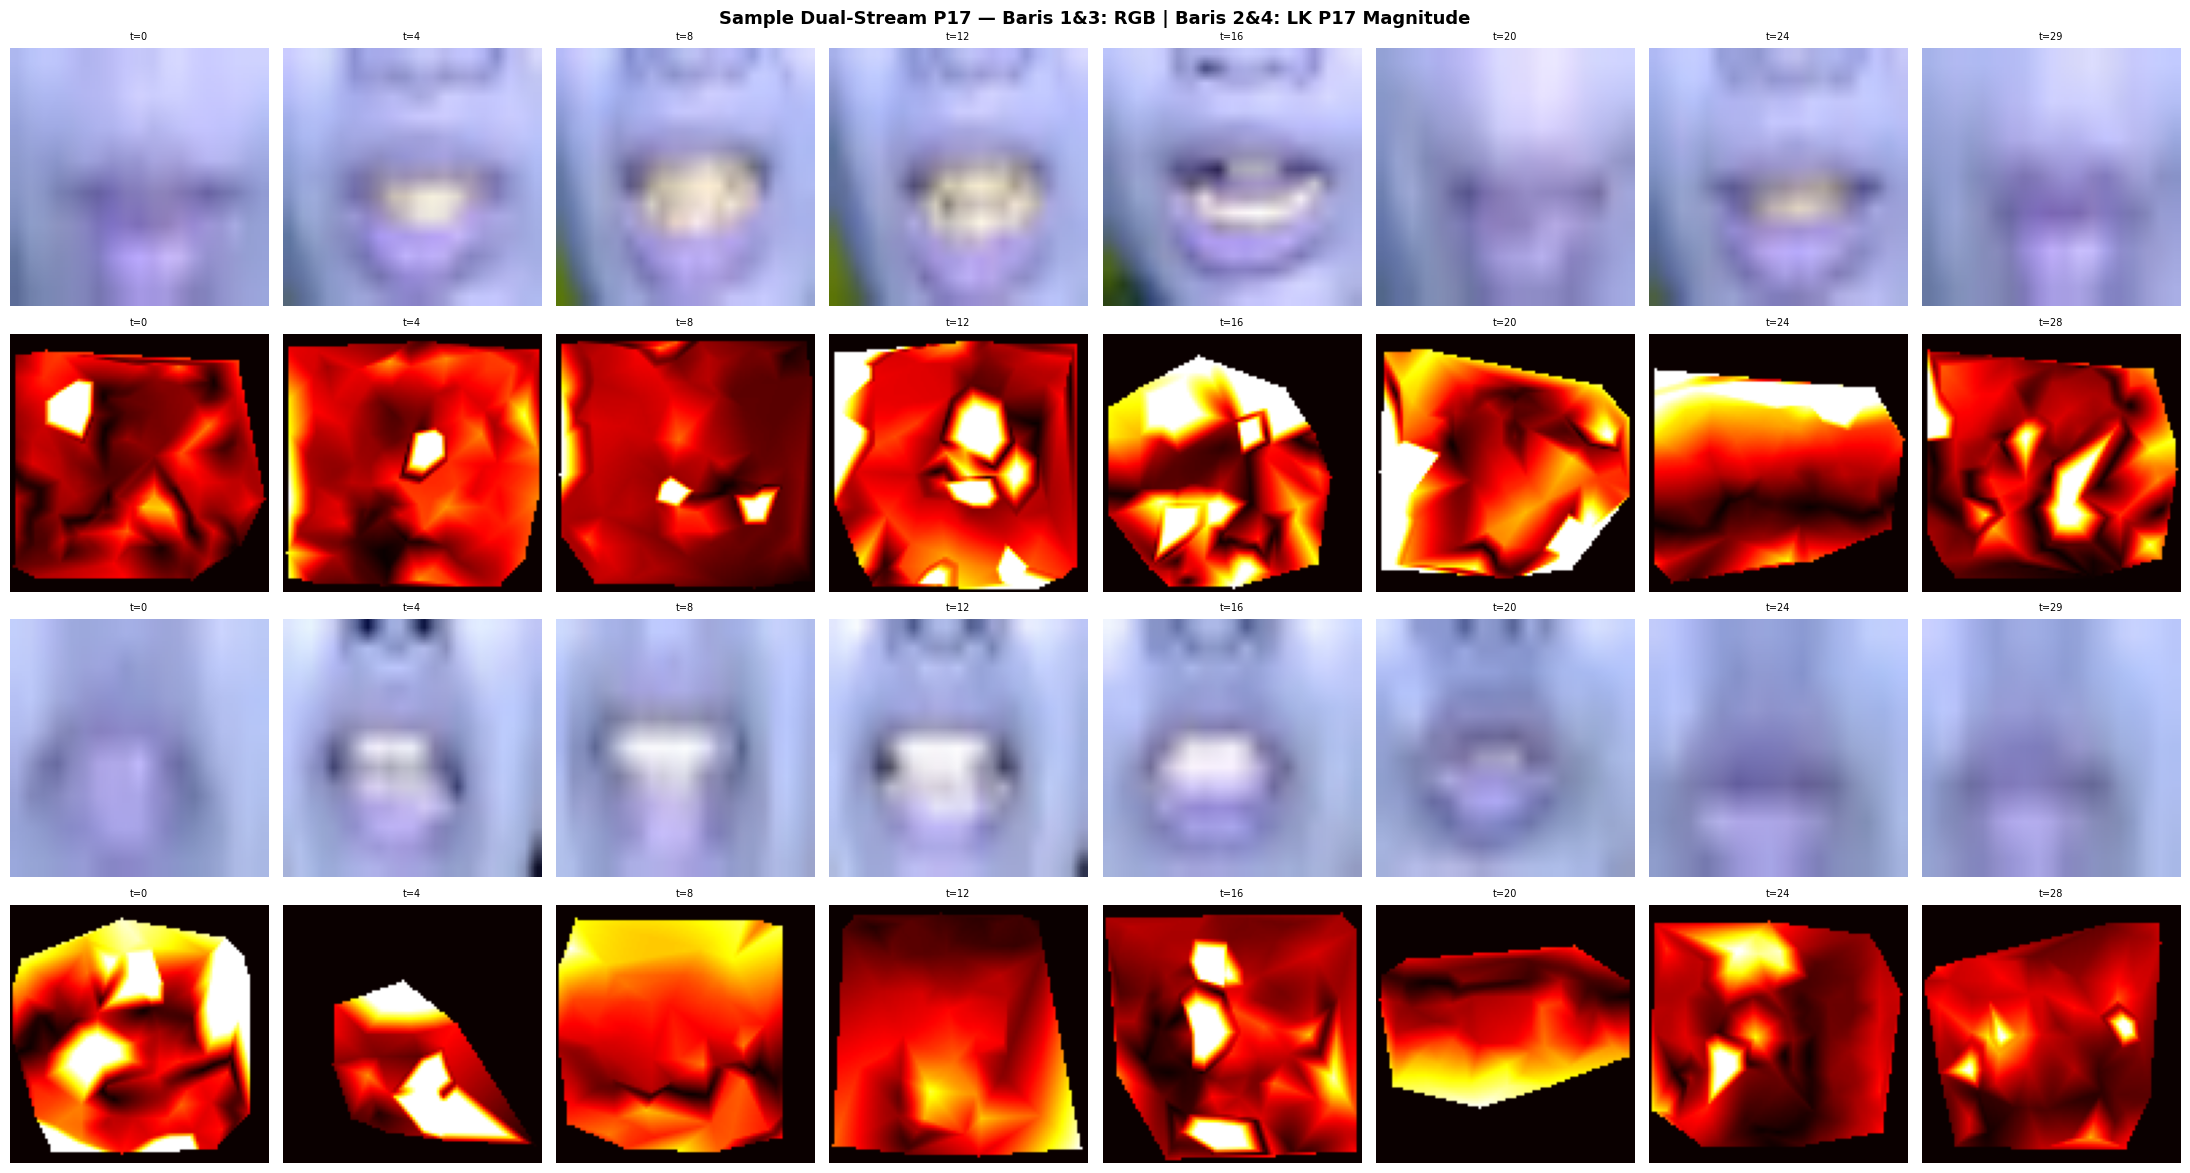

Saved: sample_dual_frames.png


In [5]:
# ── Cell 5: Visualisasi sampel ──────────────────────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(22, 12))
fig.suptitle('Sample Dual-Stream P17 — Baris 1&3: RGB | Baris 2&4: LK P17 Magnitude',
             fontsize=13, fontweight='bold')

for row in range(2):
    rgb_s, flow_s, lbl = train_ds[random.randint(0, len(train_ds)-1)]
    cls_name = IDX_TO_CLASS[lbl.item()]
    for col, t_rgb in enumerate(np.linspace(0, RGB_SEQ_LEN-1, 8, dtype=int)):
        frame = rgb_s[:, t_rgb].permute(1, 2, 0).numpy()
        axes[row*2][col].imshow(frame)
        axes[row*2][col].set_title(f't={t_rgb}', fontsize=7)
        axes[row*2][col].axis('off')
        t_fl = min(t_rgb, FLOW_SEQ_LEN - 1)
        axes[row*2+1][col].imshow(flow_s[2, t_fl].numpy(), cmap='hot')
        axes[row*2+1][col].set_title(f't={t_fl}', fontsize=7)
        axes[row*2+1][col].axis('off')
    axes[row*2][0].set_ylabel(f'RGB\n"{cls_name}"', fontsize=9, fontweight='bold')
    axes[row*2+1][0].set_ylabel(f'LK P17 mag\n"{cls_name}"', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_dual_frames.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_dual_frames.png')

In [6]:
# ── Cell 6: ConvLSTM Cell ───────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    """
    ConvLSTM menggantikan matrix multiplication LSTM dengan Conv2D.
    Informasi spasial tetap terjaga di dalam hidden state.
    Ref: Shi et al. (2015), NeurIPS.
    """
    def __init__(self, in_ch, h_ch, k=3):
        super().__init__()
        self.h_ch = h_ch
        self.conv = nn.Conv2d(in_ch + h_ch, 4 * h_ch, k, padding=k // 2)

    def forward(self, x, state):
        h, c = state
        i, f, o, g = torch.split(self.conv(torch.cat([x, h], dim=1)), self.h_ch, dim=1)
        c_next = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, B, H, W, dev):
        return (torch.zeros(B, self.h_ch, H, W, device=dev),
                torch.zeros(B, self.h_ch, H, W, device=dev))


# ── Cell 7: Stream Encoder ───────────────────────────────────────────────────
class StreamEncoder(nn.Module):
    """
    Encoder per-stream: Conv2D spatial → ConvLSTM temporal → feature 64-dim.
    Arsitektur identik dengan single-stream LK P17 (06c),
    bedanya output adalah feature vector bukan logit langsung.
    """
    def __init__(self, in_ch=3):
        super().__init__()
        def cblock(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1),
                nn.BatchNorm2d(oc),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )
        self.cnn   = nn.Sequential(cblock(in_ch, 32), cblock(32, 64), cblock(64, 128))
        self.lstm1 = ConvLSTMCell(128, 128)
        self.lstm2 = ConvLSTMCell(128, 64)

    def forward(self, x):
        B, C, T, H, W = x.shape
        x = x.permute(0, 2, 1, 3, 4).reshape(B*T, C, H, W)
        x = self.cnn(x)
        _, c, h, w = x.shape
        x = x.view(B, T, c, h, w)

        h1, c1 = self.lstm1.init_hidden(B, h, w, x.device)
        h2, c2 = self.lstm2.init_hidden(B, h, w, x.device)
        for t in range(T):
            h1, c1 = self.lstm1(x[:, t], (h1, c1))
            h2, c2 = self.lstm2(h1, (h2, c2))

        return h2.mean(dim=[-2, -1])   # [B, 64]


# ── Cell 8: Attention Fusion ─────────────────────────────────────────────────
class AttentionFusion(nn.Module):
    """
    Bobot adaptif per stream. P17 menggunakan maxCorners lebih banyak (300)
    dan qualityLevel lebih rendah (0.005) sehingga titik yang di-track lebih
    banyak di area yang kurang kuat — gate_flow bisa belajar menyeleksi ini.
    """
    def __init__(self, feat_dim=64):
        super().__init__()
        self.w_rgb  = nn.Linear(feat_dim * 2, feat_dim)
        self.w_flow = nn.Linear(feat_dim * 2, feat_dim)

    def forward(self, rgb_feat, flow_feat):
        combined  = torch.cat([rgb_feat, flow_feat], dim=1)
        gate_rgb  = torch.sigmoid(self.w_rgb(combined))
        gate_flow = torch.sigmoid(self.w_flow(combined))
        return gate_rgb * rgb_feat + gate_flow * flow_feat


# ── Cell 9: Model Utama ───────────────────────────────────────────────────────
class DualStreamModel(nn.Module):
    """
    Dual-Stream Conv-LSTM (RGB + LK P17):
    - RGB stream  → StreamEncoder → rgb_feat  [B, 64]
    - Flow stream → StreamEncoder → flow_feat [B, 64]
    - AttentionFusion → fused [B, 64]
    - Classifier: FC(64→256) + ReLU + Dropout + FC(256→N)
    """
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        self.rgb_enc  = StreamEncoder(in_ch=3)
        self.flow_enc = StreamEncoder(in_ch=3)
        self.fusion   = AttentionFusion(feat_dim=64)
        self.head     = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, rgb, flow):
        rgb_feat  = self.rgb_enc(rgb)
        flow_feat = self.flow_enc(flow)
        fused     = self.fusion(rgb_feat, flow_feat)
        return self.head(fused)

In [7]:
# ── Cell 10: Init model + ukur efisiensi ────────────────────────────────────
model = DualStreamModel(num_classes=NUM_CLASSES, dropout=0.5).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb    = total_params * 4 / 1e6

dummy_rgb  = torch.randn(1, 3, RGB_SEQ_LEN,  96, 96).to(device)
dummy_flow = torch.randn(1, 3, FLOW_SEQ_LEN, 96, 96).to(device)

try:
    from thop import profile
    macs, _ = profile(model, inputs=(dummy_rgb, dummy_flow), verbose=False)
    gflops  = macs * 2 / 1e9
    gflops_str = f'{gflops:.3f} GFLOPs'
except ImportError:
    gflops = total_params * (RGB_SEQ_LEN + FLOW_SEQ_LEN) * 2 / 1e9
    gflops_str = f'~{gflops:.3f} GFLOPs (estimasi)'

model.eval()
with torch.no_grad():
    for _ in range(5): _ = model(dummy_rgb, dummy_flow)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(50): _ = model(dummy_rgb, dummy_flow)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    infer_ms = (time.time() - t0) / 50 * 1000
model.train()

with torch.no_grad():
    test_out = model(torch.randn(2,3,RGB_SEQ_LEN,96,96).to(device),
                     torch.randn(2,3,FLOW_SEQ_LEN,96,96).to(device))

print('=' * 62)
print('  MODEL SUMMARY — Dual-Stream RGB + LK P17')
print('=' * 62)
print(f'  Arsitektur       : 2× StreamEncoder + AttentionFusion')
print(f'  RGB input        : [B, 3, {RGB_SEQ_LEN}, 96, 96]')
print(f'  Flow input       : [B, 3, {FLOW_SEQ_LEN}, 96, 96]  (u, v, magnitude — P17)')
print(f'  LK P17 params    : maxCorners=300, qualityLevel=0.005')
print(f'  Total params     : {total_params:,}')
print(f'  Trainable params : {trainable_params:,}')
print(f'  Model size       : {model_size_mb:.2f} MB (float32)')
print(f'  GFLOPs           : {gflops_str}')
print(f'  Inference time   : {infer_ms:.2f} ms/sample (GPU)')
print(f'  Output shape     : {test_out.shape}  (expected [2, {NUM_CLASSES}])')
print('=' * 62)

  MODEL SUMMARY — Dual-Stream RGB + LK P17
  Arsitektur       : 2× StreamEncoder + AttentionFusion
  RGB input        : [B, 3, 30, 96, 96]
  Flow input       : [B, 3, 29, 96, 96]  (u, v, magnitude — P17)
  LK P17 params    : maxCorners=300, qualityLevel=0.005
  Total params     : 3,470,738
  Trainable params : 3,470,738
  Model size       : 13.88 MB (float32)
  GFLOPs           : ~0.410 GFLOPs (estimasi)
  Inference time   : 16.65 ms/sample (GPU)
  Output shape     : torch.Size([2, 18])  (expected [2, 18])


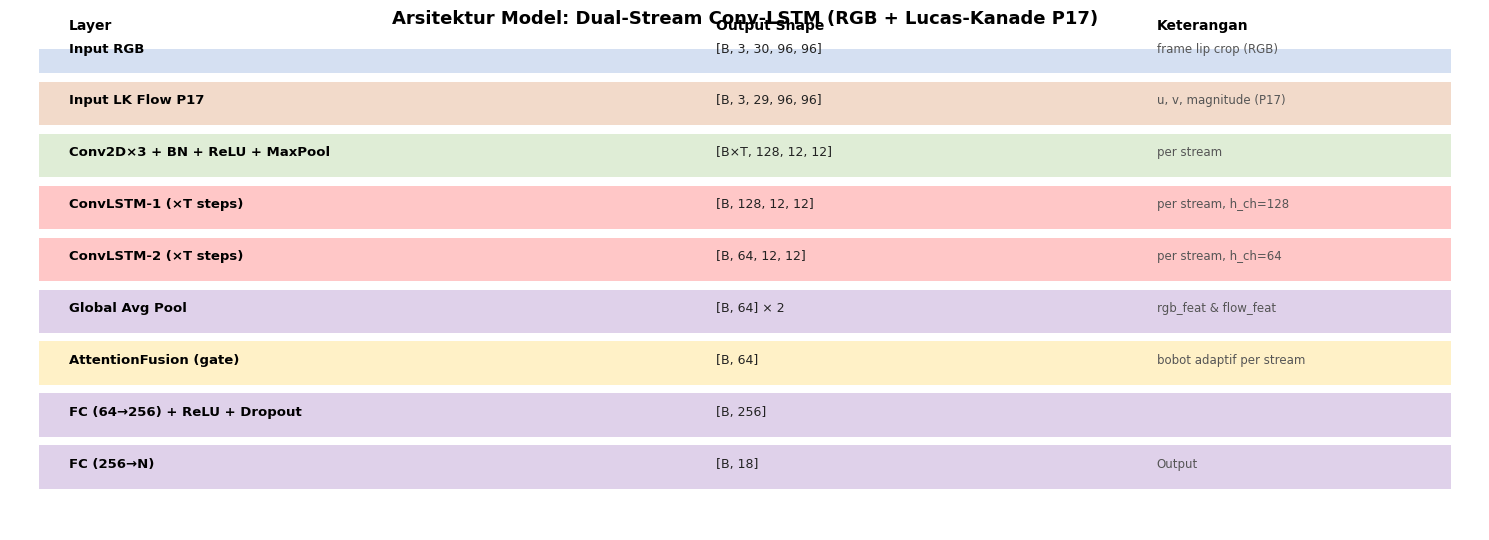

Saved: model_architecture.png


In [8]:
# ── Cell 11: Visualisasi arsitektur model ───────────────────────────────────
layers_info = [
    ('Input RGB',                      f'[B, 3, {RGB_SEQ_LEN}, 96, 96]',   'frame lip crop (RGB)'),
    ('Input LK Flow P17',              f'[B, 3, {FLOW_SEQ_LEN}, 96, 96]',  'u, v, magnitude (P17)'),
    ('Conv2D×3 + BN + ReLU + MaxPool', '[B×T, 128, 12, 12]',               'per stream'),
    ('ConvLSTM-1 (×T steps)',          '[B, 128, 12, 12]',                  'per stream, h_ch=128'),
    ('ConvLSTM-2 (×T steps)',          '[B, 64, 12, 12]',                   'per stream, h_ch=64'),
    ('Global Avg Pool',                '[B, 64] × 2',                        'rgb_feat & flow_feat'),
    ('AttentionFusion (gate)',          '[B, 64]',                            'bobot adaptif per stream'),
    ('FC (64→256) + ReLU + Dropout',   '[B, 256]',                           ''),
    ('FC (256→N)',                      f'[B, {NUM_CLASSES}]',                'Output'),
]

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.axis('off')
colors = ['#4472C4', '#C55A11', '#70AD47', '#FF0000', '#FF0000',
          '#7030A0', '#FFC000', '#7030A0', '#7030A0']

for i, (name, shape, note) in enumerate(layers_info):
    y = 1 - i * 0.108
    ax.add_patch(plt.Rectangle((0.02, y-0.05), 0.96, 0.09,
                                facecolor=colors[i], alpha=0.22, transform=ax.transAxes))
    ax.text(0.04, y, name,  transform=ax.transAxes, va='center', fontsize=9.5, fontweight='bold')
    ax.text(0.48, y, shape, transform=ax.transAxes, va='center', fontsize=9,   color='#222')
    ax.text(0.78, y, note,  transform=ax.transAxes, va='center', fontsize=8.5, color='#555')

ax.text(0.04, 1.04, 'Layer',        transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.48, 1.04, 'Output Shape', transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.78, 1.04, 'Keterangan',  transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.set_title('Arsitektur Model: Dual-Stream Conv-LSTM (RGB + Lucas-Kanade P17)',
             fontsize=13, fontweight='bold', pad=18)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_architecture.png')

In [9]:
# ── Cell 12: Loss, optimizer, scheduler ─────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8, min_lr=1e-6)

print('Loss      : CrossEntropyLoss')
print('Optimizer : Adam')
print('Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=8)')
print('Grad clip : max_norm=1.0')


# ── Cell 13: Fungsi train & eval ────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, total = 0., 0, 0
    for rgb, flow, y in tqdm(loader, desc='Train', leave=False):
        rgb, flow, y = rgb.to(device), flow.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(rgb, flow)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_sum += loss.item() * y.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += y.size(0)
    return loss_sum / total, 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0., 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for rgb, flow, y in tqdm(loader, desc='Eval', leave=False):
            rgb, flow, y = rgb.to(device), flow.to(device), y.to(device)
            out  = model(rgb, flow)
            loss = criterion(out, y)
            loss_sum += loss.item() * y.size(0)
            pred = out.argmax(1)
            correct  += (pred == y).sum().item()
            total    += y.size(0)
            all_preds.extend(pred.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    avg_loss = loss_sum / total
    accuracy = 100. * correct / total
    per_class = {}
    for ci in range(NUM_CLASSES):
        mask = [l == ci for l in all_labels]
        if any(mask):
            c = sum(p == ci for p, m in zip(all_preds, mask) if m)
            per_class[ci] = 100. * c / sum(mask)
        else:
            per_class[ci] = 0.
    return avg_loss, accuracy, per_class, all_preds, all_labels

print('setup selesai')

Loss      : CrossEntropyLoss
Optimizer : Adam
Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=8)
Grad clip : max_norm=1.0
setup selesai


In [10]:
# ── Cell 14: Training loop ──────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
           'lr': [], 'epoch_time': []}

best_val_acc    = 0.
best_epoch      = 0
best_model_path = MODELS_DIR / 'dualstream_lk_p17_gabungan_best.pth'

t_start = time.time()
print(f'Training {NUM_EPOCHS} epochs | {len(train_loader)} batches/epoch | {NUM_CLASSES} kelas\n')
print(f'{"Epoch":>6}  {"TrainLoss":>10} {"TrainAcc":>9} {"ValLoss":>9} {"ValAcc":>8}  {"LR":>8}  {"Time":>6}  {"Flag"}')
print('-' * 90)

for epoch in range(1, NUM_EPOCHS + 1):
    t_ep = time.time()

    tr_loss, tr_acc                = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc, per_cls, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(va_acc)
    cur_lr     = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - t_ep

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['lr'].append(cur_lr)
    history['epoch_time'].append(epoch_time)

    flag = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_epoch   = epoch
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'             : va_acc,
            'val_loss'            : va_loss,
            'num_classes'         : NUM_CLASSES,
            'classes'             : CLASSES,
            'method'              : 'dual-stream-lucaskanade-p17'
        }, best_model_path)
        flag = '<-- best'

    print(f'{epoch:6d}  {tr_loss:10.4f} {tr_acc:9.2f}% {va_loss:9.4f} {va_acc:8.2f}%  {cur_lr:8.2e}  {epoch_time:5.0f}s  {flag}')
    cls_str = '  '.join([f'{IDX_TO_CLASS[k]}:{v:.0f}%' for k, v in per_cls.items()])
    print(f'         per-class: {cls_str}')

    if torch.cuda.is_available() and epoch % 5 == 0:
        torch.cuda.empty_cache()

total_time = time.time() - t_start
print('\n' + '=' * 90)
print(f'Training selesai dalam {total_time/60:.1f} menit')
print(f'Best val acc: {best_val_acc:.2f}% di epoch {best_epoch}')
print(f'Model disimpan: {best_model_path}')

Training 100 epochs | 315 batches/epoch | 18 kelas

 Epoch   TrainLoss  TrainAcc   ValLoss   ValAcc        LR    Time  Flag
------------------------------------------------------------------------------------------


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

     1      2.8292     10.28%    3.2369     6.67%  1.00e-03    116s  <-- best
         per-class: 1:0%  2:0%  3:0%  8:0%  9:0%  10:0%  a:0%  b:0%  c:0%  d:0%  e:0%  f:0%  buku:0%  dia:85%  saya:0%  keliling:35%  kelompok:0%  sekarang:0%


Train:   0%|          | 0/315 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

    99      0.0021     99.96%    0.9118    85.42%  1.25e-04    115s  
         per-class: 1:98%  2:98%  3:80%  8:95%  9:95%  10:90%  a:95%  b:90%  c:72%  d:62%  e:72%  f:88%  buku:98%  dia:75%  saya:82%  keliling:85%  kelompok:85%  sekarang:78%


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

   100      0.0021     99.96%    0.8997    85.42%  1.25e-04    115s  
         per-class: 1:98%  2:95%  3:85%  8:95%  9:95%  10:98%  a:95%  b:90%  c:75%  d:68%  e:62%  f:82%  buku:98%  dia:68%  saya:85%  keliling:85%  kelompok:88%  sekarang:78%

Training selesai dalam 192.9 menit
Best val acc: 86.53% di epoch 84
Model disimpan: /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/models/dualstream_lk_p17_gabungan_best.pth


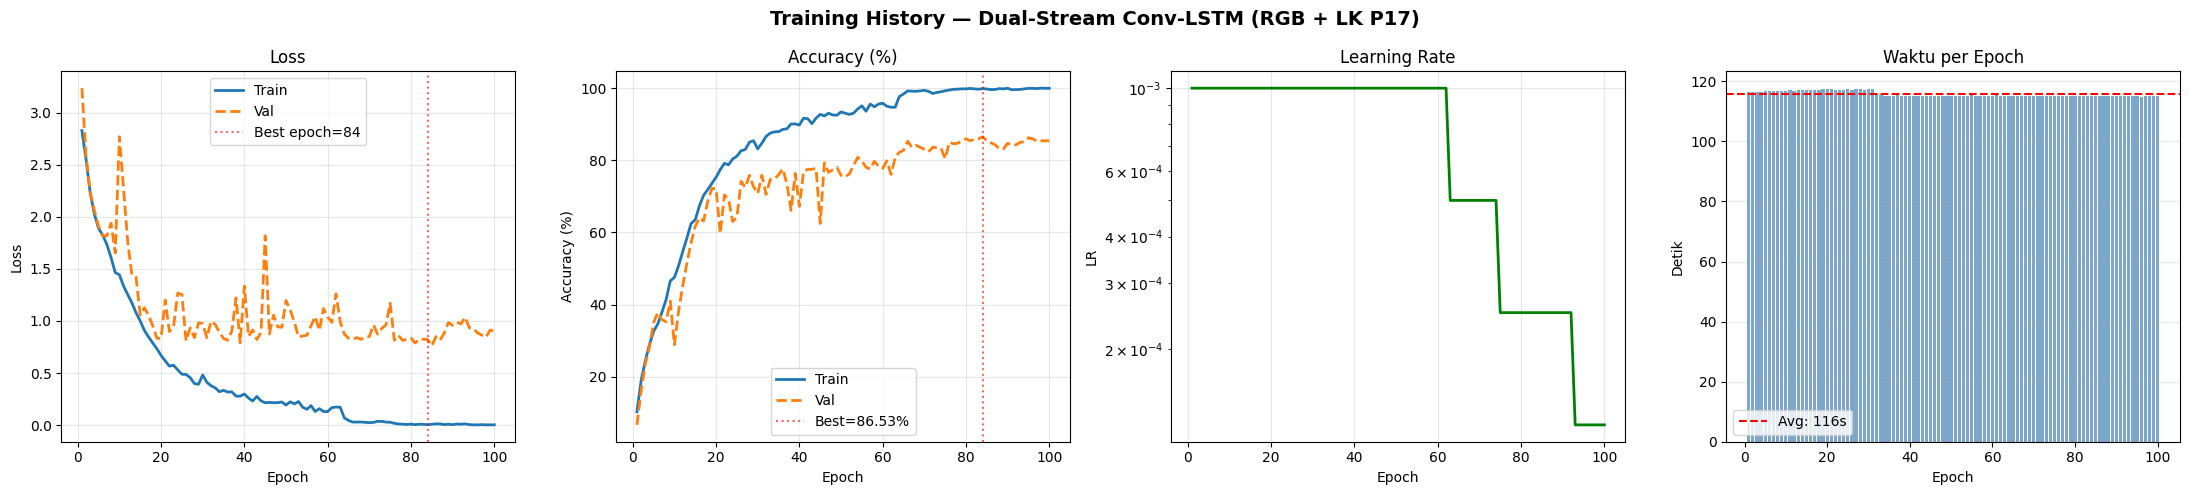

Saved: training_curves.png


In [11]:
# ── Cell 15: Training curves ────────────────────────────────────────────────
ep_ran   = len(history['train_loss'])
ep_range = range(1, ep_ran + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Training History — Dual-Stream Conv-LSTM (RGB + LK P17)', fontsize=14, fontweight='bold')

axes[0].plot(ep_range, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(ep_range, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
axes[0].axvline(best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best epoch={best_epoch}')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(ep_range, history['val_acc'],   label='Val',   linewidth=2, linestyle='--')
axes[1].axvline(best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best={best_val_acc:.2f}%')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep_range, history['lr'], linewidth=2, color='green')
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

axes[3].bar(ep_range, history['epoch_time'], color='steelblue', alpha=0.7)
axes[3].axhline(np.mean(history['epoch_time']), color='red', linestyle='--',
                label=f'Avg: {np.mean(history["epoch_time"]):.0f}s')
axes[3].set_title('Waktu per Epoch'); axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('Detik')
axes[3].legend(); axes[3].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

In [12]:
# ── Cell 16: Load best model & evaluasi test set ────────────────────────────
ckpt = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best model epoch {ckpt["epoch"]} (val acc: {ckpt["val_acc"]:.2f}%)\n')

test_loss, test_acc, test_per_cls, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

f1_macro   = f1_score(test_labels, test_preds, average='macro')    * 100
f1_weight  = f1_score(test_labels, test_preds, average='weighted') * 100
prec_macro = precision_score(test_labels, test_preds, average='macro',    zero_division=0) * 100
rec_macro  = recall_score(test_labels,   test_preds, average='macro',     zero_division=0) * 100
prec_w     = precision_score(test_labels, test_preds, average='weighted', zero_division=0) * 100
rec_w      = recall_score(test_labels,   test_preds, average='weighted',  zero_division=0) * 100

print('\n' + '=' * 62)
print('  HASIL EVALUASI TEST SET — Dual-Stream RGB + LK P17')
print('=' * 62)
print(f'  Test Loss             : {test_loss:.4f}')
print(f'  Test Accuracy         : {test_acc:.2f}%')
print(f'  Precision (macro)     : {prec_macro:.2f}%')
print(f'  Precision (weighted)  : {prec_w:.2f}%')
print(f'  Recall    (macro)     : {rec_macro:.2f}%')
print(f'  Recall    (weighted)  : {rec_w:.2f}%')
print(f'  F1-score  (macro)     : {f1_macro:.2f}%')
print(f'  F1-score  (weighted)  : {f1_weight:.2f}%')
print('=' * 62)

Loaded best model epoch 84 (val acc: 86.53%)



Eval:   0%|          | 0/45 [00:00<?, ?it/s]


  HASIL EVALUASI TEST SET — Dual-Stream RGB + LK P17
  Test Loss             : 0.8598
  Test Accuracy         : 86.07%
  Precision (macro)     : 86.70%
  Precision (weighted)  : 86.68%
  Recall    (macro)     : 86.04%
  Recall    (weighted)  : 86.07%
  F1-score  (macro)     : 85.93%
  F1-score  (weighted)  : 85.94%


In [13]:
# ── Cell 17: Classification report ─────────────────────────────────────────
print('Classification Report per Kelas:\n')
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=3))

Classification Report per Kelas:

              precision    recall  f1-score   support

           1      0.870     1.000     0.930        20
           2      0.857     0.900     0.878        20
           3      0.875     0.700     0.778        20
           8      0.826     0.950     0.884        20
           9      0.933     0.737     0.824        19
          10      0.909     1.000     0.952        20
           a      1.000     0.900     0.947        20
           b      0.833     1.000     0.909        20
           c      0.875     0.700     0.778        20
           d      0.692     0.900     0.783        20
           e      0.944     0.850     0.895        20
           f      0.950     0.950     0.950        20
        buku      0.857     0.900     0.878        20
         dia      0.889     0.800     0.842        20
        saya      0.727     0.800     0.762        20
    keliling      0.778     0.700     0.737        20
    kelompok      0.889     0.800     0.842    

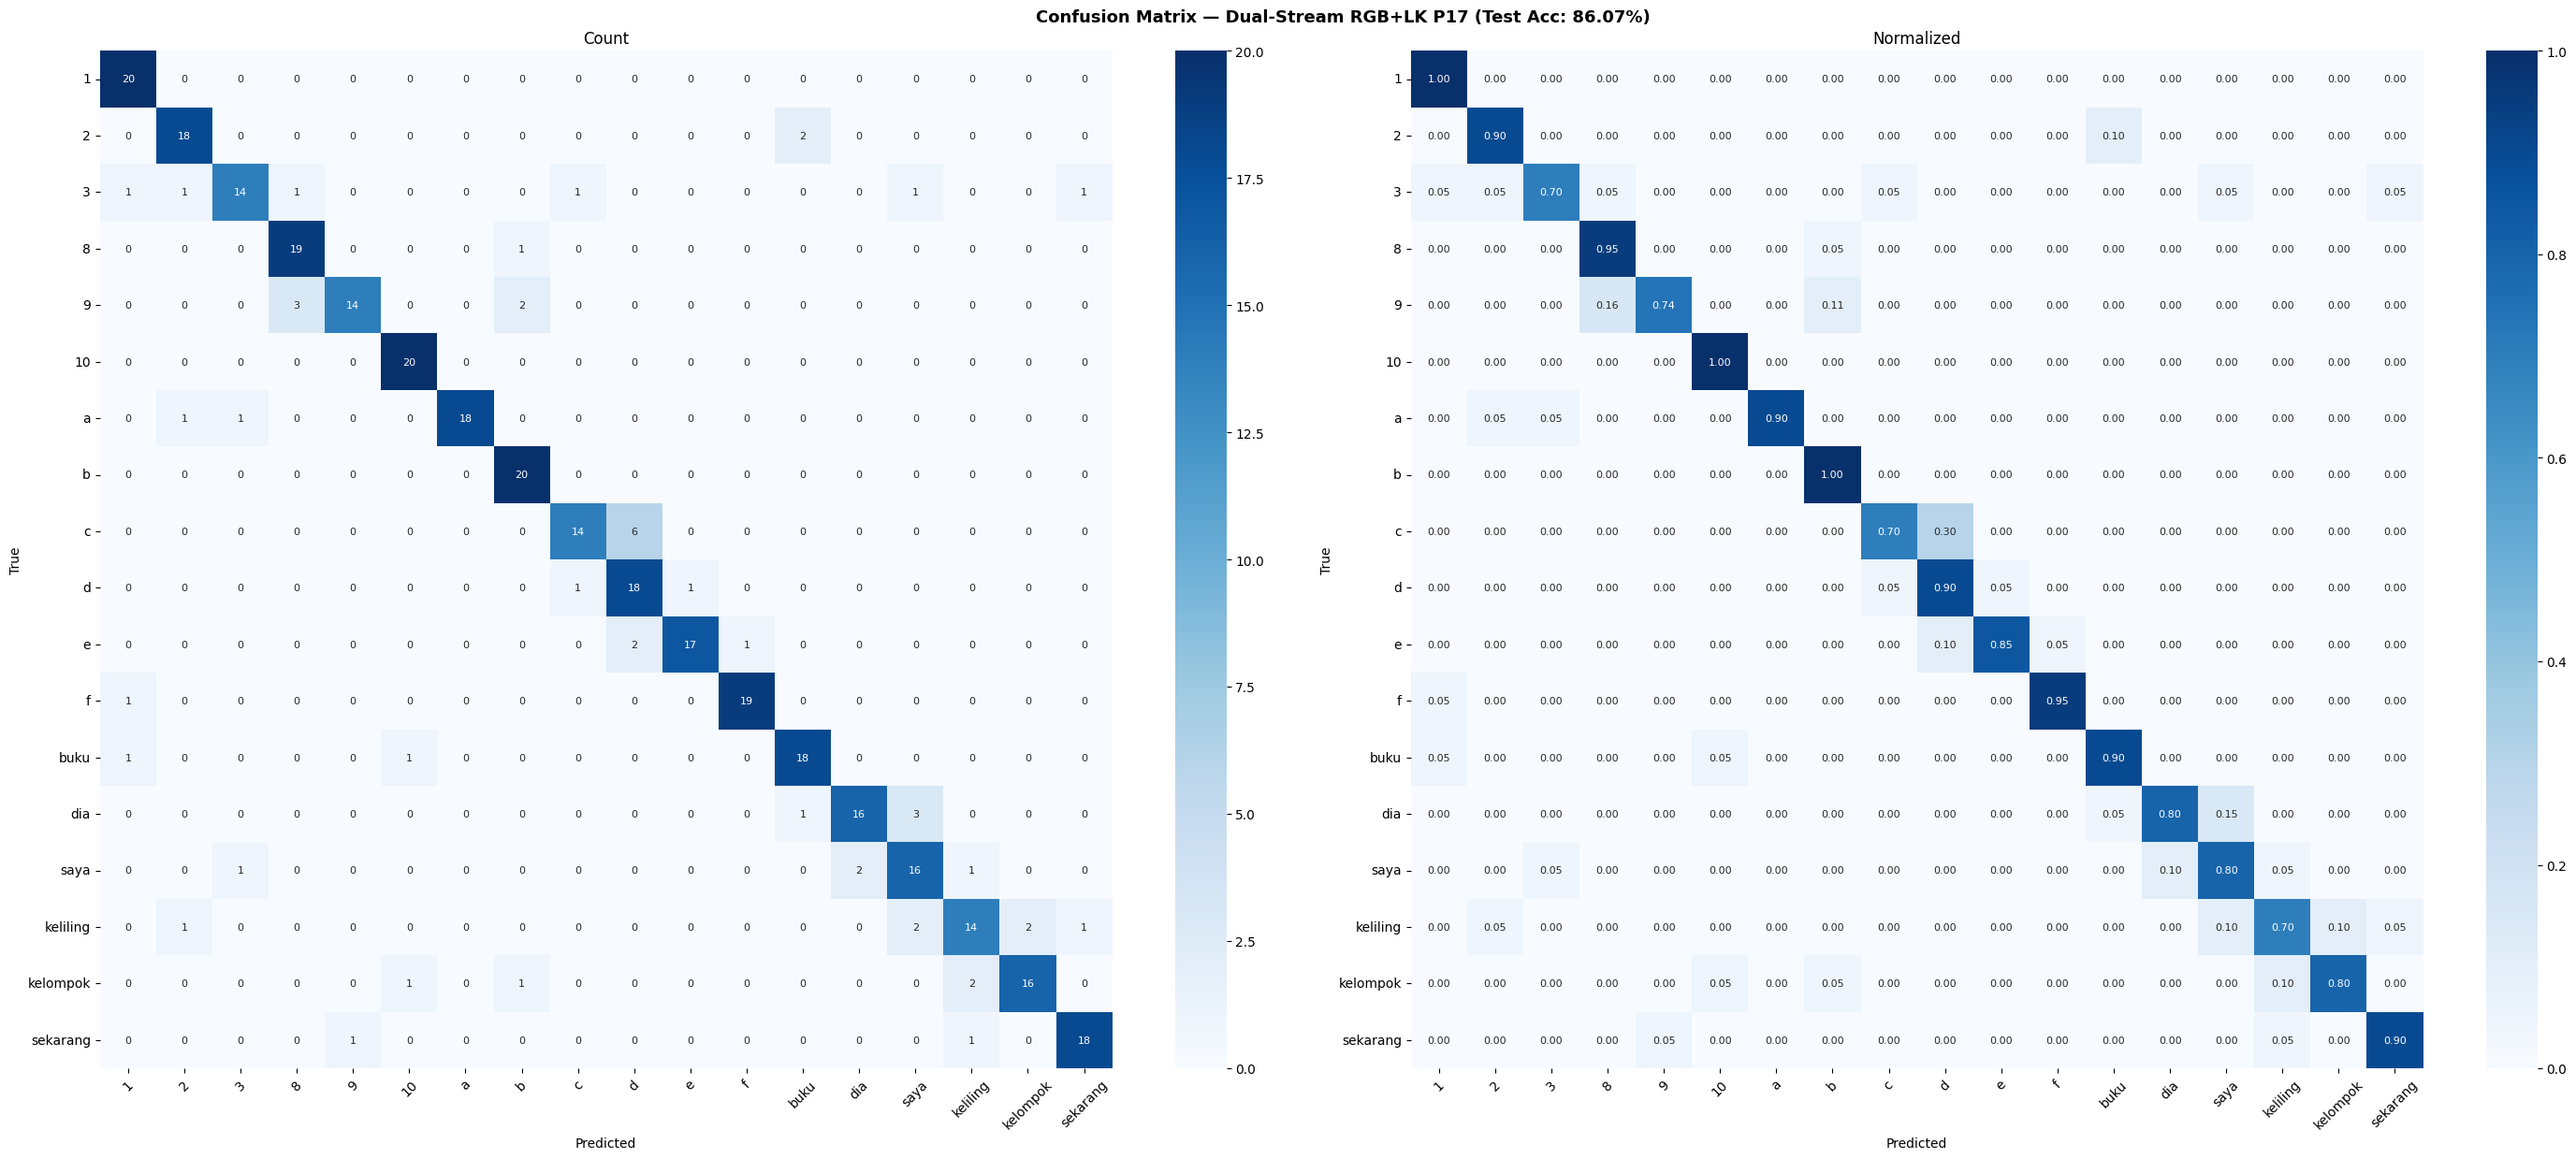

Saved: confusion_matrix.png


In [14]:
# ── Cell 18: Confusion matrix ───────────────────────────────────────────────
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig_w = max(14, NUM_CLASSES * 0.8)
fig_h = max(10, NUM_CLASSES * 0.7)
fig, axes = plt.subplots(1, 2, figsize=(fig_w * 2, fig_h))
fig.suptitle(f'Confusion Matrix — Dual-Stream RGB+LK P17 (Test Acc: {test_acc:.2f}%)',
             fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 8})
axes[0].set_title('Count'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 8}, vmin=0, vmax=1)
axes[1].set_title('Normalized'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

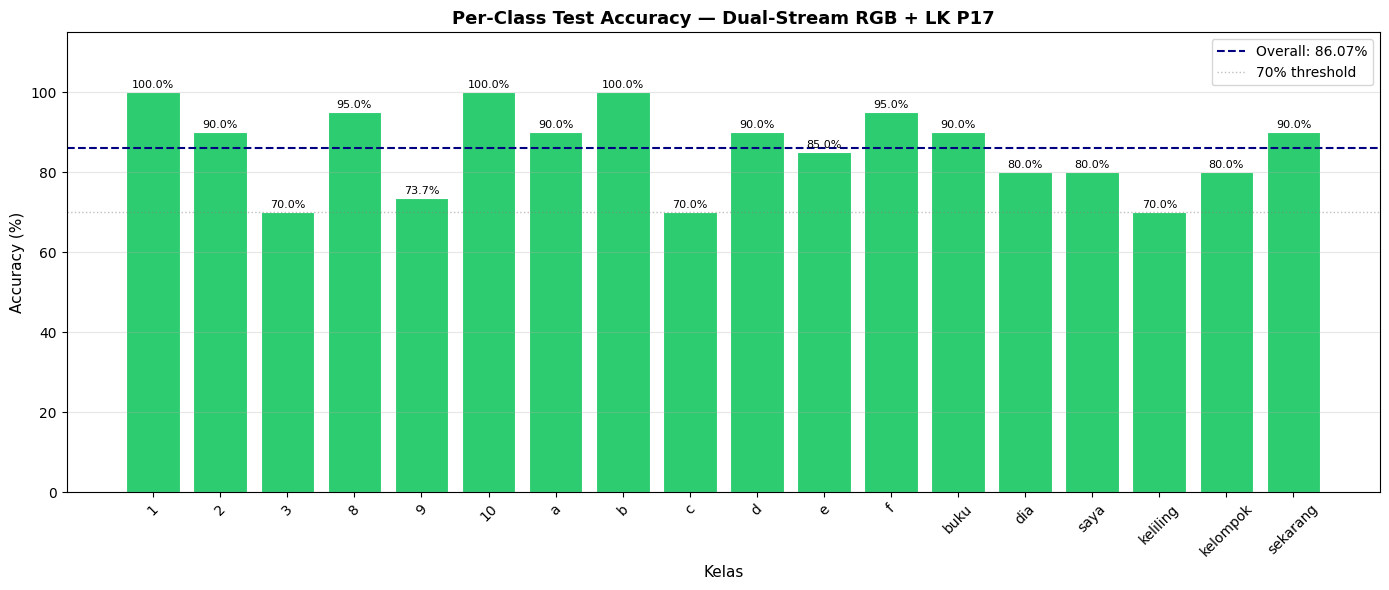

Saved: per_class_accuracy.png


In [15]:
# ── Cell 19: Per-class accuracy bar chart ───────────────────────────────────
class_accs = [test_per_cls[i] for i in range(NUM_CLASSES)]
colors_bar = ['#2ecc71' if a >= 70 else '#e67e22' if a >= 40 else '#e74c3c' for a in class_accs]

fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES * 0.7), 6))
bars = ax.bar(CLASSES, class_accs, color=colors_bar, edgecolor='white', linewidth=0.8)
for bar, acc in zip(bars, class_accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)
ax.axhline(test_acc, color='navy', linestyle='--', linewidth=1.5, label=f'Overall: {test_acc:.2f}%')
ax.axhline(70, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='70% threshold')
ax.set_xlabel('Kelas', fontsize=11); ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Test Accuracy — Dual-Stream RGB + LK P17', fontsize=13, fontweight='bold')
ax.set_ylim([0, 115]); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_accuracy.png')

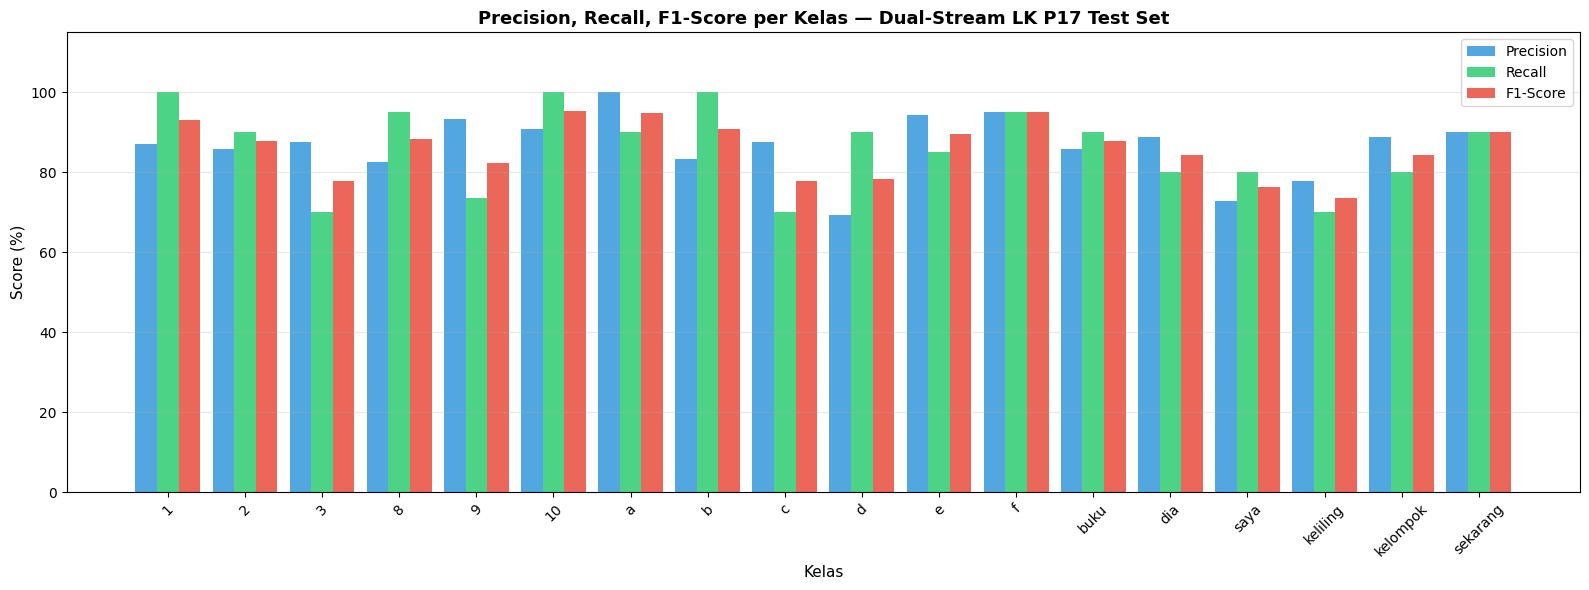

Saved: precision_recall_f1.png


In [16]:
# ── Cell 20: Precision, Recall, F1 per kelas ─────────────────────────────────
report_dict = classification_report(
    test_labels, test_preds, target_names=CLASSES, output_dict=True, zero_division=0
)

prec_per = [report_dict[c]['precision'] * 100 for c in CLASSES]
rec_per  = [report_dict[c]['recall']    * 100 for c in CLASSES]
f1_per   = [report_dict[c]['f1-score']  * 100 for c in CLASSES]

x_pos = np.arange(NUM_CLASSES)
width = 0.28

fig, ax = plt.subplots(figsize=(max(16, NUM_CLASSES * 0.8), 6))
ax.bar(x_pos - width, prec_per, width, label='Precision', color='#3498db', alpha=0.85)
ax.bar(x_pos,         rec_per,  width, label='Recall',    color='#2ecc71', alpha=0.85)
ax.bar(x_pos + width, f1_per,   width, label='F1-Score',  color='#e74c3c', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(CLASSES, rotation=45)
ax.set_xlabel('Kelas', fontsize=11); ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Precision, Recall, F1-Score per Kelas — Dual-Stream LK P17 Test Set',
             fontsize=13, fontweight='bold')
ax.set_ylim([0, 115]); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'precision_recall_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: precision_recall_f1.png')

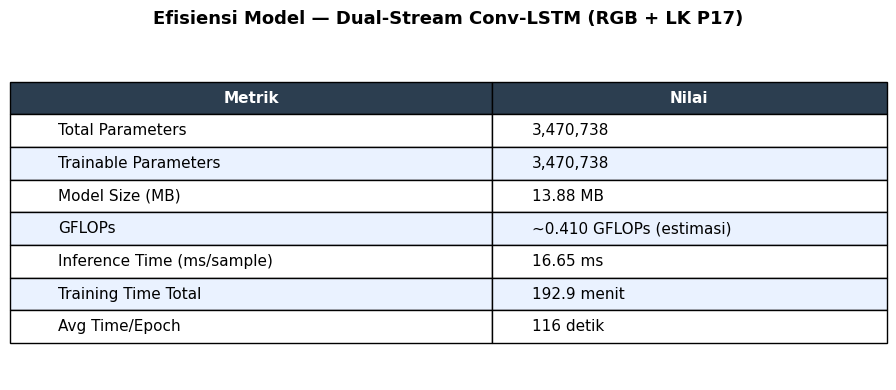

Saved: model_efficiency.png


In [17]:
# ── Cell 21: Ringkasan efisiensi model ──────────────────────────────────────
efficiency_data = {
    'Metrik' : ['Total Parameters', 'Trainable Parameters', 'Model Size (MB)',
                 'GFLOPs', 'Inference Time (ms/sample)',
                 'Training Time Total', 'Avg Time/Epoch'],
    'Nilai'  : [
        f'{total_params:,}',
        f'{trainable_params:,}',
        f'{model_size_mb:.2f} MB',
        gflops_str,
        f'{infer_ms:.2f} ms',
        f'{total_time/60:.1f} menit',
        f'{np.mean(history["epoch_time"]):.0f} detik'
    ]
}

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
df_eff = pd.DataFrame(efficiency_data)
tbl = ax.table(cellText=df_eff.values, colLabels=df_eff.columns,
               cellLoc='left', loc='center', colWidths=[0.55, 0.45])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EAF2FF')
ax.set_title('Efisiensi Model — Dual-Stream Conv-LSTM (RGB + LK P17)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_efficiency.png')

In [18]:
# ── Cell 22: Tabel perbandingan semua metode ────────────────────────────────
comparison = {
    'Baseline RGB Conv-LSTM'               : {'val': 84.58, 'test': 83.06},
    'LK default Conv-LSTM'                 : {'val': 51.67, 'test': 50.83},
    'LK P17 Conv-LSTM'                     : {'val': 52.08, 'test': 51.25},
    'Dual-Stream RGB + LK default'         : {'val': None,  'test': None},   # isi dari 07
    'Dual-Stream RGB + LK P17 (ini)'       : {'val': best_val_acc, 'test': test_acc},
}

print('=' * 72)
print('PERBANDINGAN METODE — Dataset Gabungan (18 kelas)')
print('=' * 72)
print(f'{"Metode":<52} {"Val Acc":>9} {"Test Acc":>9}')
print('-' * 72)
for nama, res in comparison.items():
    v = f'{res["val"]:.2f}%'  if res['val']  is not None else 'N/A'
    t = f'{res["test"]:.2f}%' if res['test'] is not None else 'N/A'
    print(f'{nama:<52} {v:>9}  {t:>9}')
print('=' * 72)

delta_val  = best_val_acc - comparison['Baseline RGB Conv-LSTM']['val']
delta_test = test_acc     - comparison['Baseline RGB Conv-LSTM']['test']
print(f'\nDelta Dual P17 vs Baseline — Val : {delta_val:+.2f}% | Test: {delta_test:+.2f}%')

delta_vs_lk_default_test = test_acc - comparison['LK P17 Conv-LSTM']['test']
print(f'Delta Dual P17 vs LK P17 single  — Test: {delta_vs_lk_default_test:+.2f}%')

PERBANDINGAN METODE — Dataset Gabungan (18 kelas)
Metode                                                 Val Acc  Test Acc
------------------------------------------------------------------------
Baseline RGB Conv-LSTM                                  84.58%     83.06%
LK default Conv-LSTM                                    51.67%     50.83%
LK P17 Conv-LSTM                                        52.08%     51.25%
Dual-Stream RGB + LK default                               N/A        N/A
Dual-Stream RGB + LK P17 (ini)                          86.53%     86.07%

Delta Dual P17 vs Baseline — Val : +1.95% | Test: +3.01%
Delta Dual P17 vs LK P17 single  — Test: +34.82%


In [19]:
# ── Cell 23: Save summary JSON + CSV ───────────────────────────────────────
summary = {
    'model'     : 'Dual-Stream Conv2D + ConvLSTM (RGB + Lucas-Kanade P17)',
    'dataset'   : 'SIBI Dependent Gabungan',
    'lk_params' : 'P17: maxCorners=300, qualityLevel=0.005',
    'model_info': {
        'total_params'    : total_params,
        'trainable_params': trainable_params,
        'model_size_mb'   : round(model_size_mb, 2),
        'gflops'          : gflops_str,
        'inference_ms'    : round(infer_ms, 2),
        'rgb_input'       : f'[B, 3, {RGB_SEQ_LEN}, 96, 96]',
        'flow_input'      : f'[B, 3, {FLOW_SEQ_LEN}, 96, 96]'
    },
    'training'  : {
        'epochs_trained'    : ep_ran,
        'best_epoch'        : best_epoch,
        'batch_size'        : BATCH_SIZE,
        'learning_rate'     : LR,
        'weight_decay'      : WEIGHT_DECAY,
        'optimizer'         : 'Adam',
        'scheduler'         : 'ReduceLROnPlateau (max, factor=0.5, patience=8)',
        'augmentation'      : 'horizontal flip + negate u channel',
        'grad_clip'         : 'max_norm=1.0',
        'best_val_acc'      : round(best_val_acc, 4),
        'total_time_minutes': round(total_time / 60, 2),
        'avg_epoch_time_sec': round(np.mean(history['epoch_time']), 1)
    },
    'test_results': {
        'test_loss'         : round(test_loss, 4),
        'accuracy'          : round(test_acc, 4),
        'precision_macro'   : round(prec_macro, 4),
        'precision_weighted': round(prec_w, 4),
        'recall_macro'      : round(rec_macro, 4),
        'recall_weighted'   : round(rec_w, 4),
        'f1_macro'          : round(f1_macro, 4),
        'f1_weighted'       : round(f1_weight, 4),
        'per_class_acc'     : {CLASSES[i]: round(acc, 2) for i, acc in enumerate(class_accs)}
    }
}

with open(RESULTS_DIR / 'dualstream_lk_p17_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    'epoch'      : range(1, ep_ran + 1),
    'train_loss' : history['train_loss'],
    'train_acc'  : history['train_acc'],
    'val_loss'   : history['val_loss'],
    'val_acc'    : history['val_acc'],
    'lr'         : history['lr'],
    'epoch_time' : history['epoch_time']
}).to_csv(RESULTS_DIR / 'training_history.csv', index=False)

report_rows = []
for cls in CLASSES:
    r = report_dict[cls]
    report_rows.append({'class': cls, 'precision': round(r['precision']*100, 2),
                        'recall': round(r['recall']*100, 2), 'f1': round(r['f1-score']*100, 2),
                        'support': int(r['support'])})
pd.DataFrame(report_rows).to_csv(RESULTS_DIR / 'classification_report.csv', index=False)

print('Files saved:')
all_files = [
    ('models',  'dualstream_lk_p17_gabungan_best.pth'),
    ('results', 'dualstream_lk_p17_summary.json'),
    ('results', 'training_history.csv'),
    ('results', 'classification_report.csv'),
    ('results', 'model_architecture.png'),
    ('results', 'sample_dual_frames.png'),
    ('results', 'training_curves.png'),
    ('results', 'confusion_matrix.png'),
    ('results', 'per_class_accuracy.png'),
    ('results', 'precision_recall_f1.png'),
    ('results', 'model_efficiency.png'),
]
for kind, fname in all_files:
    path = (MODELS_DIR if kind == 'models' else RESULTS_DIR) / fname
    print(f'  [{"✓" if path.exists() else "○"}] {fname}')

print(f'\nDual-Stream LK P17 Training selesai!')
print(f'Test Accuracy  : {test_acc:.2f}%')
print(f'F1 (weighted)  : {f1_weight:.2f}%')
print(f'Best epoch     : {best_epoch}/{ep_ran}')
print(f'Delta vs Baseline — Test: {test_acc - 83.06:+.2f}%')

Files saved:
  [✓] dualstream_lk_p17_gabungan_best.pth
  [✓] dualstream_lk_p17_summary.json
  [✓] training_history.csv
  [✓] classification_report.csv
  [✓] model_architecture.png
  [✓] sample_dual_frames.png
  [✓] training_curves.png
  [✓] confusion_matrix.png
  [✓] per_class_accuracy.png
  [✓] precision_recall_f1.png
  [✓] model_efficiency.png

Dual-Stream LK P17 Training selesai!
Test Accuracy  : 86.07%
F1 (weighted)  : 85.94%
Best epoch     : 84/100
Delta vs Baseline — Test: +3.01%
